In [2]:
import pandas as pd
import numpy as np

DATA CLEANING

In [3]:
file_path = "C:/Users/AditiRidhi/Downloads/Song_Dataset.xlsx"

sheet1 = pd.read_excel(file_path, sheet_name=0)
sheet2 = pd.read_excel(file_path, sheet_name=1)

In [4]:
sheet1.head()
sheet2.head()

sheet1.info()
sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Song_Id               949 non-null    object 
 1   track_name            949 non-null    object 
 2   artist(s)_name        949 non-null    object 
 3   artist_count          949 non-null    int64  
 4   released_year         949 non-null    int64  
 5   released_month        949 non-null    object 
 6   released_day          949 non-null    int64  
 7   in_spotify_playlists  949 non-null    int64  
 8   in_spotify_charts     949 non-null    int64  
 9   streams               949 non-null    object 
 10  in_apple_playlists    949 non-null    int64  
 11  in_apple_charts       949 non-null    int64  
 12  in_deezer_playlists   949 non-null    int64  
 13  in_deezer_charts      949 non-null    int64  
 14  in_shazam_charts      898 non-null    float64
 15  bpm                   9

In [5]:
sheet1['Song_Id'] = sheet1['Song_Id'].astype(str).str.replace(',', '').str.strip()

sheet2['Song_Id'] = sheet2['Song_Id'].astype(str).str.lstrip('0')

In [6]:
sheet1['released_month'] = sheet1['released_month'].astype(str)

month_map = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}

sheet1['released_month'] = sheet1['released_month'].replace(month_map)

sheet1['released_month'] = pd.to_numeric(sheet1['released_month'], errors='coerce')

In [7]:
sheet1['release_date'] = pd.to_datetime(
    sheet1['released_year'].astype(str) + '-' +
    sheet1['released_month'].astype(str) + '-' +
    sheet1['released_day'].astype(str),
    errors='coerce'
)

In [8]:
sheet1[['released_year','released_month','released_day','release_date']].head(10)

,released_year,released_month,released_day,release_date
0,2023,7,14,2023-07-14
1,2023,3,23,2023-03-23
2,2023,6,30,2023-06-30
3,2019,8,23,2019-08-23
4,2025,5,18,2025-05-18
5,2023,6,1,2023-06-01
6,2023,3,16,2023-03-16
7,2023,7,7,2023-07-07
8,2023,5,15,2023-05-15
9,2023,3,17,2023-03-17


In [9]:
numeric_cols = [
    'streams', 'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts', 'bpm'
]

for col in numeric_cols:
    sheet1[col] = pd.to_numeric(sheet1[col], errors='coerce')

In [10]:
percent_cols = [
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%'
]

for col in percent_cols:
    sheet2[col] = pd.to_numeric(sheet2[col], errors='coerce')

In [11]:
sheet1.isnull().sum()
sheet2.isnull().sum()

sheet1.fillna(sheet1.median(numeric_only=True), inplace=True)
sheet2.fillna(sheet2.median(numeric_only=True), inplace=True)

In [12]:
sheet1.drop_duplicates(inplace=True)
sheet2.drop_duplicates(inplace=True)

In [13]:
sheet1.info()
sheet2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 941 entries, 0 to 948
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Song_Id               941 non-null    object        
 1   track_name            941 non-null    object        
 2   artist(s)_name        941 non-null    object        
 3   artist_count          941 non-null    int64         
 4   released_year         941 non-null    int64         
 5   released_month        941 non-null    int64         
 6   released_day          941 non-null    int64         
 7   in_spotify_playlists  941 non-null    int64         
 8   in_spotify_charts     941 non-null    int64         
 9   streams               941 non-null    float64       
 10  in_apple_playlists    941 non-null    int64         
 11  in_apple_charts       941 non-null    int64         
 12  in_deezer_playlists   941 non-null    int64         
 13  in_deezer_charts      941

In [14]:
with pd.ExcelWriter("C:/Users/AditiRidhi/Downloads/cleaned_spotify_data.xlsx", engine="openpyxl") as writer:
    sheet1.to_excel(writer, sheet_name="Song Details_Clean", index=False)
    sheet2.to_excel(writer, sheet_name="Node Details_Clean", index=False)

In [15]:
sheet2_clean = sheet2.groupby('Song_Id', as_index=False).mean()

In [16]:
merged_df = pd.merge(sheet1, sheet2_clean, on='Song_Id', how='left')

In [17]:
merged_df.shape
merged_df.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,...,key,mode,release_date,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,...,B,Major,2023-07-14,69.0,89.0,83.0,18.0,0.0,8.0,4.0
1,3628,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,...,C#,Major,2023-03-23,75.5,42.5,69.5,12.5,0.0,9.5,5.0
2,3520,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,...,F,Major,2023-06-30,51.0,32.0,53.0,17.0,0.0,31.0,6.0
3,3362,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,...,A,Major,2019-08-23,55.0,58.0,72.0,11.0,0.0,11.0,15.0
4,3914,WHERE SHE GOES,Bad Bunny,1,2025,5,18,3133,50,303236322.0,...,A,Minor,2025-05-18,65.0,23.0,80.0,14.0,63.0,11.0,6.0


In [18]:
merged_df.isnull().sum()

Song_Id                  0
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts         0
bpm                      0
key                     95
mode                     0
release_date             0
danceability_%           4
valence_%                4
energy_%                 4
acousticness_%           4
instrumentalness_%       4
liveness_%               4
speechiness_%            4
dtype: int64

In [19]:
merged_df['key'] = merged_df['key'].fillna('Unknown')

In [20]:
merged_df['key'].isnull().sum()

0

FINAL CLEAN & MERGED DATA

In [21]:
merged_df

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,...,key,mode,release_date,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,...,B,Major,2023-07-14,69.0,89.0,83.0,18.0,0.0,8.0,4.0
1,3628,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,...,C#,Major,2023-03-23,75.5,42.5,69.5,12.5,0.0,9.5,5.0
2,3520,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,...,F,Major,2023-06-30,51.0,32.0,53.0,17.0,0.0,31.0,6.0
3,3362,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,...,A,Major,2019-08-23,55.0,58.0,72.0,11.0,0.0,11.0,15.0
4,3914,WHERE SHE GOES,Bad Bunny,1,2025,5,18,3133,50,303236322.0,...,A,Minor,2025-05-18,65.0,23.0,80.0,14.0,63.0,11.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,3898,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363.0,...,A,Major,2022-11-03,60.0,24.0,39.0,57.0,0.0,8.0,3.0
937,4471,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870.0,...,F#,Major,2022-10-21,42.0,7.0,24.0,83.0,1.0,12.0,6.0
938,4482,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683.0,...,C#,Major,2022-11-03,80.0,81.0,67.0,4.0,0.0,8.0,6.0
939,4881,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612.0,...,C#,Major,2022-10-20,82.0,67.0,77.0,8.0,0.0,12.0,5.0


In [22]:
merged_df['unique_song'] = (
    merged_df['track_name'].str.strip() + '_' +
    merged_df['artist(s)_name'].str.strip()
)

In [24]:
merged_df1 = merged_df.drop_duplicates(subset='unique_song').copy()

In [25]:
with pd.ExcelWriter("C:/Users/AditiRidhi/Downloads/cleaned & merged_spotify_data.xlsx", engine="openpyxl") as writer:
    merged_df1.to_excel(writer, sheet_name="Merged Data", index=False)
    

In [26]:
audio_cols = [
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%'
]

for col in audio_cols:
    merged_df1[col] = pd.to_numeric(merged_df1[col], errors='coerce')
    merged_df1[col].fillna(merged_df1[col].median(), inplace=True)

In [27]:
popularity_cols = [
    'streams',
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_charts',
    'in_deezer_charts',
    'in_shazam_charts'
]

for col in popularity_cols:
    merged_df1.loc[:, col] = (
        (merged_df1[col] - merged_df1[col].min()) /
        (merged_df1[col].max() - merged_df1[col].min())
    )

merged_df1.loc[:, 'popularity_score'] = merged_df1[popularity_cols].mean(axis=1)

In [28]:
merged_df1.shape
merged_df1.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,...,release_date,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,unique_song,popularity_score
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,0.009818,1.000000,0.038170,...,2023-07-14,69.0,89.0,83.0,18.0,0.0,8.0,4.0,"Seven (feat. Latto) (Explicit Ver.)_Latto, Jun...",0.457671
1,3628,LALA,Myke Towers,1,2023,3,23,0.027240,0.326531,0.036101,...,2023-03-23,75.5,42.5,69.5,12.5,0.0,9.5,5.0,LALA_Myke Towers,0.225450
2,3520,vampire,Olivia Rodrigo,1,2023,6,30,0.025783,0.768707,0.037798,...,2023-06-30,51.0,32.0,53.0,17.0,0.0,31.0,6.0,vampire_Olivia Rodrigo,0.413405
3,3362,Cruel Summer,Taylor Swift,1,2019,8,23,0.148002,0.680272,0.216215,...,2019-08-23,55.0,58.0,72.0,11.0,0.0,11.0,15.0,Cruel Summer_Taylor Swift,0.396964
4,3914,WHERE SHE GOES,Bad Bunny,1,2025,5,18,0.058622,0.340136,0.081869,...,2025-05-18,65.0,23.0,80.0,14.0,63.0,11.0,6.0,WHERE SHE GOES_Bad Bunny,0.252631


In [29]:
merged_df1['popularity_score'].describe()

count    933.000000
mean       0.098230
std        0.094312
min        0.003069
25%        0.024965
50%        0.071448
75%        0.133189
max        0.642277
Name: popularity_score, dtype: float64

In [30]:
merged_df1.to_excel("final_spotify_analysis.xlsx", index=False)

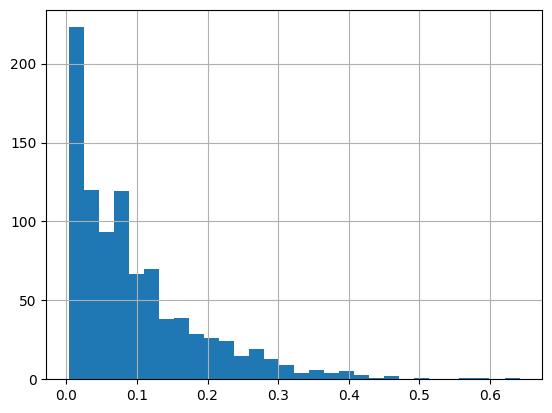

In [33]:
merged_df1['popularity_score'].hist(bins=30)
plt.show()

CORRELATION

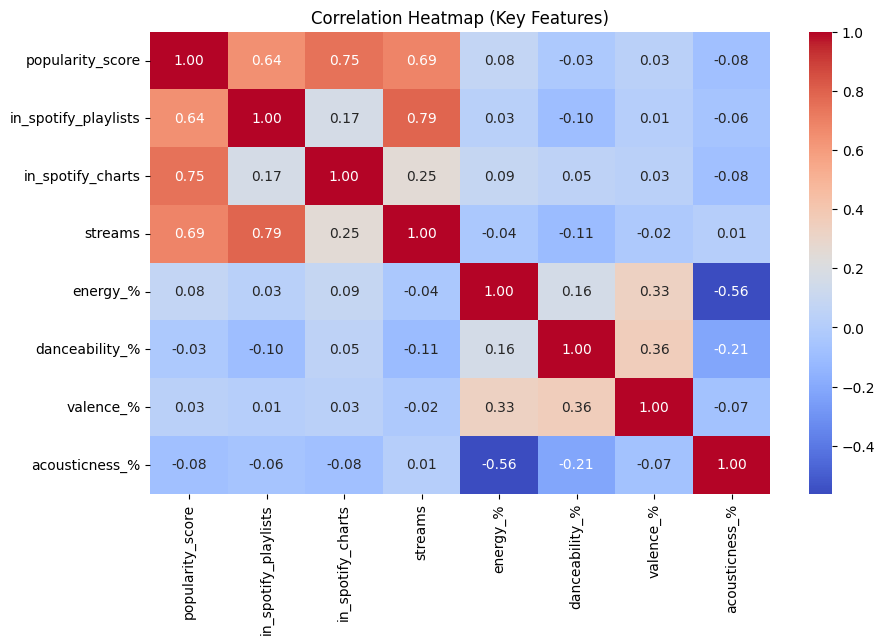

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'popularity_score',
    'in_spotify_playlists',
    'in_spotify_charts',
    'streams',
    'energy_%',
    'danceability_%',
    'valence_%',
    'acousticness_%'
]

corr = merged_df1[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Key Features)")
plt.show()

In [36]:
corr['popularity_score'].sort_values(ascending=False)

popularity_score        1.000000
in_spotify_charts       0.748228
streams                 0.688765
in_spotify_playlists    0.644488
energy_%                0.077680
valence_%               0.031718
danceability_%         -0.025337
acousticness_%         -0.082948
Name: popularity_score, dtype: float64

In [43]:
df_artist.to_excel("artist by popularity.xlsx", index=False)